# Notebook 1: Implementación de DBSCAN con librerías

**Estudiantes:**  
Mateo Bermejo / Ronald Gómez / Adrián Murcia

**Fecha:** 26 / 05 / 26  
**Asignatura:** Minería de Datos / Inteligencia Artificial  
**Universidad:** Fundación Universitaria Los Libertadores  
**Entrega:** 1 - Asesoría de avances

## 1. Introducción

En este notebook se implementa el algoritmo **DBSCAN** utilizando librerías de Python, principalmente **scikit-learn**, para resolver un problema de **segmentación de clientes de tarjetas de crédito**.

El dataset utilizado corresponde a **Credit Card Dataset for Clustering - CCData**, el cual contiene información de comportamiento financiero de clientes, como saldo, compras, avances en efectivo, pagos, límite de crédito, frecuencia de compras, entre otras variables.

DBSCAN es un algoritmo de aprendizaje no supervisado basado en densidad. Su objetivo es encontrar grupos de datos que se encuentren cercanos entre sí y detectar registros que no pertenecen claramente a ningún grupo, conocidos como **ruido** o **valores atípicos**.

En este proyecto, DBSCAN se usa para agrupar clientes con comportamientos similares y detectar clientes con patrones inusuales de uso de tarjeta de crédito.

## 2. Fundamentos del algoritmo DBSCAN

DBSCAN significa **Density-Based Spatial Clustering of Applications with Noise**. Es un algoritmo de clustering que forma grupos según la densidad de puntos en el espacio de características.

DBSCAN trabaja principalmente con dos parámetros:

- **eps:** distancia máxima para considerar que dos puntos son vecinos.
- **min_samples:** cantidad mínima de puntos necesarios para formar una zona densa.

El algoritmo clasifica los puntos en tres tipos:

- **Punto núcleo:** tiene al menos `min_samples` vecinos dentro del radio `eps`.
- **Punto borde:** está cerca de un punto núcleo, pero no tiene suficientes vecinos para ser núcleo.
- **Ruido o anomalía:** no pertenece a ningún grupo denso. En scikit-learn se identifica con la etiqueta `-1`.

DBSCAN es útil para este problema porque no necesita conocer previamente la cantidad de clusters y permite detectar clientes con comportamientos atípicos.

## 3. Metodología y diagrama de flujo

La metodología del notebook consiste en preparar el dataset, entrenar el modelo DBSCAN con librerías, evaluar los grupos encontrados y serializar los archivos necesarios para la aplicación.

```text
Inicio
  ↓
Cargar librerías
  ↓
Cargar dataset CCData
  ↓
Explorar estructura del dataset
  ↓
Limpiar datos:
  - Eliminar columna CUST_ID
  - Rellenar valores nulos
  - Seleccionar variables numéricas
  ↓
Escalar variables con StandardScaler
  ↓
Entrenar modelo DBSCAN con scikit-learn
  ↓
Evaluar clusters:
  - Cantidad de grupos
  - Cantidad de clientes atípicos
  - Silhouette Score
  - Davies-Bouldin Score
  ↓
Visualizar resultados con PCA
  ↓
Serializar modelo, scaler e información del modelo
  ↓
Fin
```

## 4. Implementación con librerías

A diferencia de una implementación manual, en este notebook el algoritmo se construye usando librerías especializadas.

Las librerías principales son:

- **pandas:** manipulación del dataset.
- **numpy:** operaciones numéricas.
- **matplotlib:** visualización de resultados.
- **scikit-learn:** escalado, entrenamiento DBSCAN, reducción PCA y métricas.
- **joblib:** serialización del modelo entrenado.

In [2]:
# Importación de librerías principales
# Pandas permite cargar y manipular datos tabulares.
import pandas as pd

# NumPy permite realizar operaciones numéricas eficientes.
import numpy as np

# Matplotlib permite generar gráficas para analizar los resultados.
import matplotlib.pyplot as plt

# OS se usa para crear carpetas y manejar rutas del proyecto.
import os

# Joblib permite guardar y cargar modelos entrenados en formato .pkl.
import joblib

# StandardScaler se utiliza para escalar las variables numéricas.
from sklearn.preprocessing import StandardScaler

# DBSCAN es el algoritmo de clustering seleccionado para el proyecto.
from sklearn.cluster import DBSCAN

# PCA se usa para reducir dimensiones y poder visualizar los clusters en 2D.
from sklearn.decomposition import PCA

# Métricas para evaluar la calidad del agrupamiento.
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [3]:
# Creación de carpetas necesarias del proyecto.
# Esto ayuda a que el notebook pueda ejecutarse aunque las carpetas no existan todavía.

os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

print("Carpetas verificadas correctamente.")

Carpetas verificadas correctamente.


## 4. Carga y exploración del dataset CCData

El dataset debe estar ubicado en la siguiente ruta del proyecto:

```text
data/raw/CC GENERAL.csv
```

Este archivo contiene información de clientes de tarjetas de crédito. La columna `CUST_ID` funciona como identificador del cliente, por lo tanto, no se usa para entrenar el modelo.

In [4]:
# Ruta del archivo original del dataset.
ruta_dataset = "../data/raw/CC GENERAL.csv"

# Carga del dataset usando pandas.
df = pd.read_csv(ruta_dataset)

# Se muestran las dimensiones del dataset.
print("Dimensiones del dataset:", df.shape)

# Vista inicial de los primeros registros.
df.head()

Dimensiones del dataset: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Descripción de los atributos del dataset

El dataset contiene información de clientes de tarjetas de crédito. Cada registro representa un cliente y sus hábitos financieros relacionados con compras, pagos, avances de efectivo y uso del crédito.

| Atributo | Descripción |
|---|---|
| **CUST_ID** | Identificador único del cliente. No se usa directamente para entrenar el modelo porque solo sirve como código de identificación. |
| **BALANCE** | Saldo actual que tiene el cliente en la tarjeta de crédito. Representa cuánto dinero debe o mantiene pendiente. |
| **BALANCE_FREQUENCY** | Frecuencia con la que el saldo del cliente es actualizado. Valores cercanos a 1 indican que el saldo se actualiza frecuentemente. |
| **PURCHASES** | Valor total de compras realizadas por el cliente con la tarjeta de crédito. |
| **ONEOFF_PURCHASES** | Valor total de compras realizadas en una sola transacción o de contado. |
| **INSTALLMENTS_PURCHASES** | Valor total de compras realizadas en cuotas o pagos diferidos. |
| **CASH_ADVANCE** | Valor total de avances de efectivo realizados por el cliente. |
| **PURCHASES_FREQUENCY** | Frecuencia con la que el cliente realiza compras. Valores altos indican compras más frecuentes. |
| **ONEOFF_PURCHASES_FREQUENCY** | Frecuencia con la que el cliente realiza compras de contado o en una sola transacción. |
| **PURCHASES_INSTALLMENTS_FREQUENCY** | Frecuencia con la que el cliente realiza compras en cuotas. |
| **CASH_ADVANCE_FREQUENCY** | Frecuencia con la que el cliente solicita avances de efectivo. |
| **CASH_ADVANCE_TRX** | Número de transacciones de avances de efectivo realizadas por el cliente. |
| **PURCHASES_TRX** | Número total de transacciones de compra realizadas por el cliente. |
| **CREDIT_LIMIT** | Límite de crédito asignado al cliente en la tarjeta. |
| **PAYMENTS** | Valor total de pagos realizados por el cliente hacia su tarjeta de crédito. |
| **MINIMUM_PAYMENTS** | Valor mínimo de pago que el cliente debe realizar. Este campo contiene algunos valores nulos que deben ser tratados antes del entrenamiento. |
| **PRC_FULL_PAYMENT** | Porcentaje de veces en que el cliente pagó el total de la deuda de la tarjeta. |
| **TENURE** | Tiempo, en meses, que el cliente ha permanecido usando el servicio de tarjeta de crédito. |

### Observaciones iniciales

El dataset cuenta con **8950 registros** y **18 columnas**.  
La mayoría de las variables son numéricas, lo cual es adecuado para aplicar algoritmos de clustering como **DBSCAN**.  

Sin embargo, se identifican algunos aspectos importantes antes del entrenamiento:

- La columna **CUST_ID** es categórica y debe eliminarse antes de entrenar el modelo.
- Las columnas **CREDIT_LIMIT** y **MINIMUM_PAYMENTS** tienen valores nulos.
- Como DBSCAN trabaja con distancias, es necesario escalar las variables numéricas usando técnicas como **StandardScaler**.

In [5]:
# Información general del dataset.
# Permite revisar columnas, tipos de datos y cantidad de registros no nulos.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [6]:
# Revisión de valores nulos por columna.
# Esto permite identificar qué variables requieren tratamiento antes del entrenamiento.

valores_nulos = df.isnull().sum()
valores_nulos[valores_nulos > 0]

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

In [7]:
# Estadísticas descriptivas de las variables numéricas.
# Ayudan a entender la escala y distribución de los datos.

df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


# 5. EDA - Análisis Exploratorio de Datos

En esta sección se realiza el análisis exploratorio del dataset CCData con el objetivo de comprender mejor el comportamiento de las variables antes de aplicar el algoritmo DBSCAN.

El análisis incluye:

- Revisión de valores nulos.
- Distribución de variables principales.
- Análisis de correlaciones.
- Identificación visual de posibles valores atípicos.

Este paso es importante porque DBSCAN es sensible a la escala de los datos y a la presencia de valores atípicos, por lo cual se requiere entender previamente la estructura del dataset.

## 5.1 Revisión de valores nulos

Se revisan los valores nulos presentes en el dataset.  
Este paso permite identificar columnas que requieren tratamiento antes del entrenamiento del modelo.

In [21]:
# Revisión de valores nulos por columna

valores_nulos = df.isnull().sum()

print("Valores nulos por columna:")
print(valores_nulos[valores_nulos > 0])

Valores nulos por columna:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


In [22]:
# Porcentaje de valores nulos por columna

porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

print("Porcentaje de valores nulos:")
print(porcentaje_nulos[porcentaje_nulos > 0])

Porcentaje de valores nulos:
CREDIT_LIMIT        0.011173
MINIMUM_PAYMENTS    3.497207
dtype: float64


## 5.2 Distribución de variables principales

Se grafican las distribuciones de algunas variables financieras importantes del dataset.  
Esto permite observar cómo se comportan los datos y si existen concentraciones, sesgos o valores extremos.

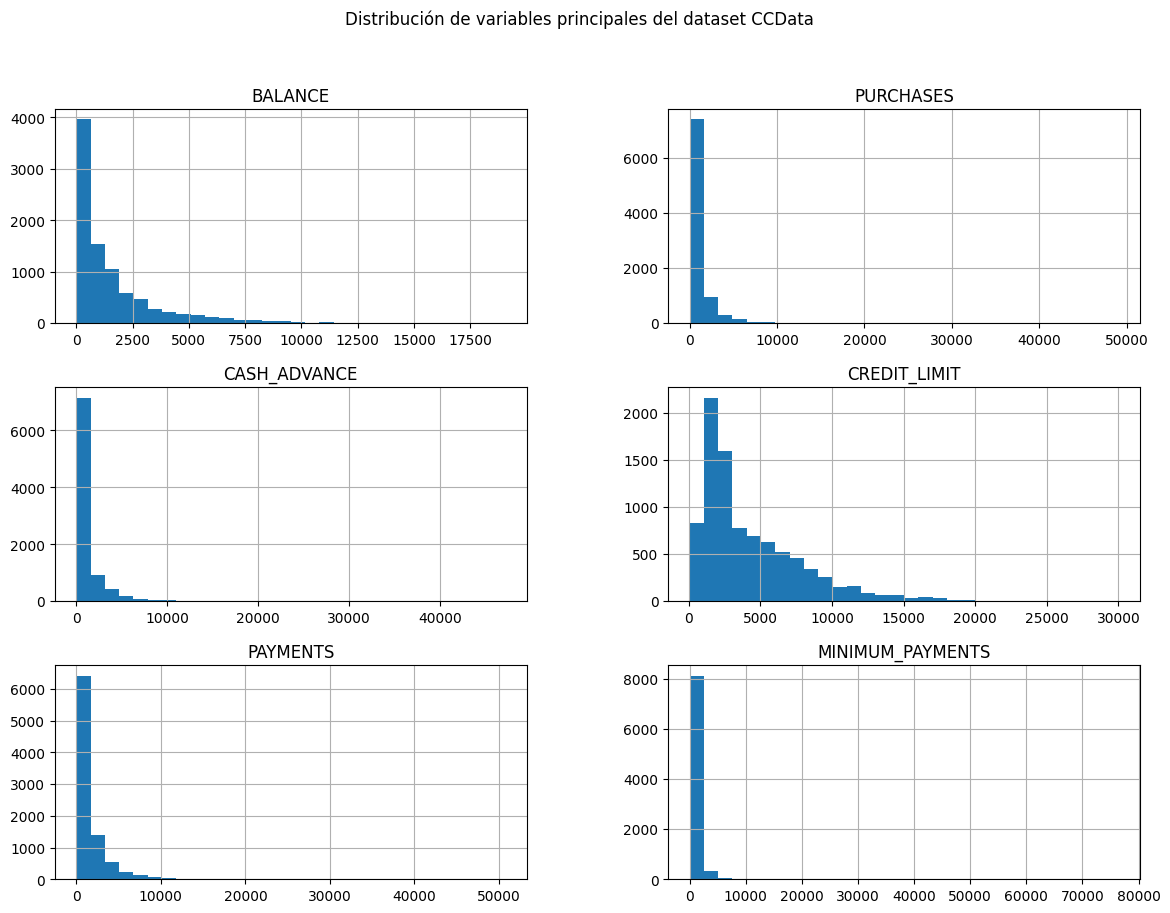

In [23]:
# Selección de variables principales para análisis visual

variables_principales = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
]

# Gráficas de distribución

df[variables_principales].hist(figsize=(14, 10), bins=30)

plt.suptitle("Distribución de variables principales del dataset CCData")
plt.show()

Las gráficas permiten observar que algunas variables presentan alta dispersión y posibles valores extremos.  
Esto es común en datos financieros, ya que no todos los clientes tienen el mismo nivel de consumo, saldo, pagos o avances en efectivo.

## 5.3 Análisis de correlaciones

Se analiza la relación entre las variables numéricas del dataset mediante un mapa de calor.  
Esto ayuda a identificar variables que tienen comportamientos similares o relaciones fuertes entre sí.

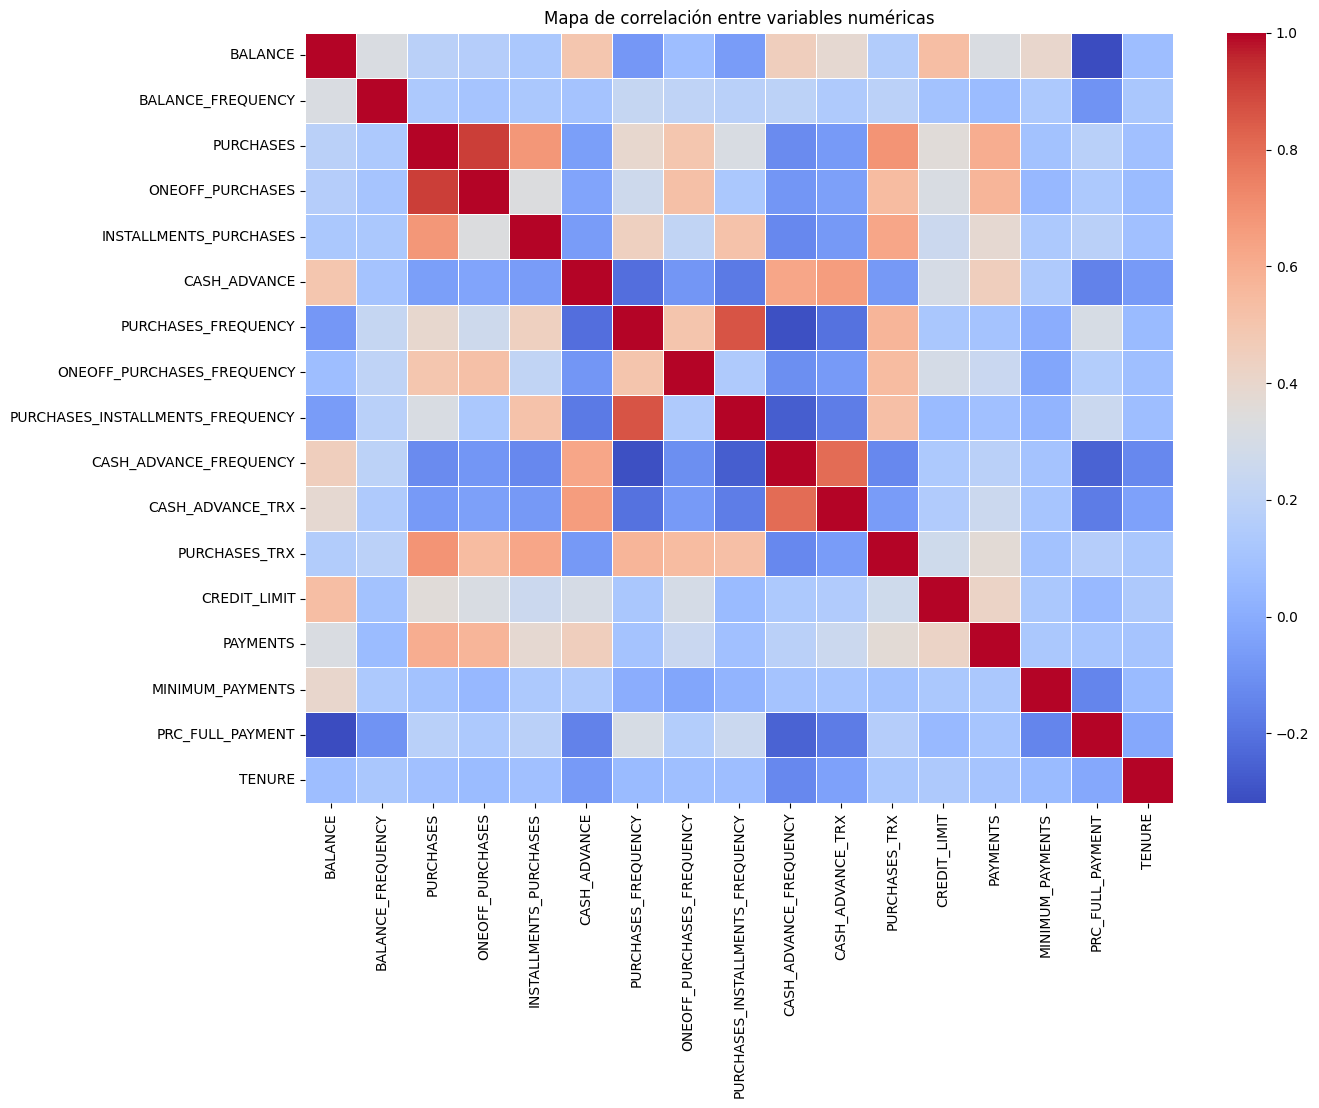

In [24]:
# Mapa de calor de correlaciones

import seaborn as sns

# Se elimina CUST_ID porque es un identificador y no aporta al análisis numérico
df_correlacion = df.drop(columns=["CUST_ID"])

plt.figure(figsize=(14, 10))

correlacion = df_correlacion.corr()

sns.heatmap(
    correlacion,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Mapa de correlación entre variables numéricas")
plt.show()

El mapa de correlación permite identificar relaciones entre variables del comportamiento financiero de los clientes.  
Por ejemplo, variables relacionadas con compras, pagos o avances en efectivo pueden presentar asociaciones importantes.

Este análisis es útil para comprender la estructura general de los datos antes de aplicar DBSCAN.

## 5.4 Análisis visual de outliers

Se realiza una revisión visual de posibles valores atípicos mediante diagramas de caja.  
Este análisis es relevante porque DBSCAN puede identificar registros atípicos como ruido, representados con la etiqueta `-1`.

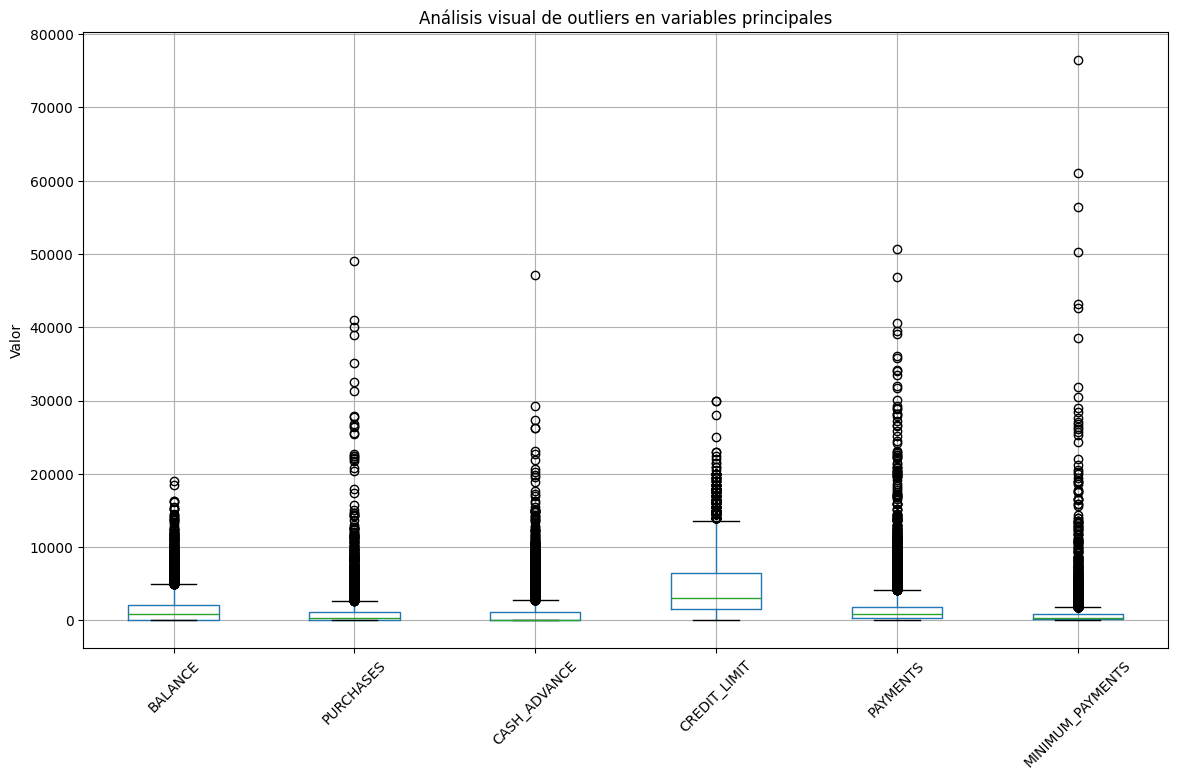

In [25]:
# Visualización de posibles outliers en variables principales

plt.figure(figsize=(14, 8))

df[variables_principales].boxplot()

plt.title("Análisis visual de outliers en variables principales")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

En los diagramas de caja se pueden observar posibles valores atípicos en algunas variables financieras.  
Estos valores no se eliminan directamente, ya que en este proyecto DBSCAN puede aprovechar esta información para detectar clientes con comportamientos inusuales.

## 5.5 Conclusión del EDA

A partir del análisis exploratorio se identificó que el dataset contiene variables numéricas relacionadas con el comportamiento financiero de clientes de tarjetas de crédito.

También se observaron valores nulos en algunas columnas, por lo que será necesario aplicar una estrategia de limpieza. Además, varias variables presentan alta dispersión y posibles valores atípicos, lo cual justifica el uso de DBSCAN como algoritmo de clustering y detección de ruido.

Debido a que las variables tienen diferentes escalas, será necesario aplicar estandarización antes del entrenamiento del modelo.

## 6. Preprocesamiento de datos

Para entrenar DBSCAN se realiza una limpieza básica:

1. Eliminar `CUST_ID` porque es un identificador y no aporta al agrupamiento.
2. Seleccionar variables numéricas.
3. Rellenar valores nulos con la mediana.
4. Escalar los datos con `StandardScaler`.

El escalado es muy importante porque DBSCAN trabaja con distancias. Si las variables tienen escalas muy diferentes, el algoritmo puede dar más importancia a las columnas con valores grandes.

In [8]:
# Se crea una copia del dataset para el procesamiento.
df_model = df.copy()

# Se elimina la columna identificadora si existe.
if "CUST_ID" in df_model.columns:
    df_model = df_model.drop(columns=["CUST_ID"])

# Se seleccionan únicamente columnas numéricas.
df_model = df_model.select_dtypes(include=[np.number])

# Se rellenan los valores nulos con la mediana de cada columna.
df_model = df_model.fillna(df_model.median())

# Se valida que no queden valores nulos.
print("Total de valores nulos después de limpieza:", df_model.isnull().sum().sum())

# Se muestran las primeras filas del dataset procesado.
df_model.head()

Total de valores nulos después de limpieza: 0


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [9]:
# Guardar dataset procesado para evidenciar el avance del proyecto.
ruta_procesado = "../data/processed/ccdata_processed.csv"
df_model.to_csv(ruta_procesado, index=False)

print("Dataset procesado guardado en:", ruta_procesado)

Dataset procesado guardado en: ../data/processed/ccdata_processed.csv


In [10]:
# Escalado de datos.
# StandardScaler transforma las variables para que tengan media 0 y desviación estándar 1.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print("Datos escalados correctamente.")
print("Forma de X_scaled:", X_scaled.shape)

Datos escalados correctamente.
Forma de X_scaled: (8950, 17)


## 7. Entrenamiento del modelo DBSCAN

En esta sección se entrena el modelo DBSCAN usando la implementación de `scikit-learn`.

Para esta primera versión del proyecto se usan parámetros iniciales:

- `eps = 2.5`
- `min_samples = 10`

Estos valores pueden ajustarse en próximas entregas para mejorar la calidad de los clusters.

In [11]:
# Entrenamiento del modelo DBSCAN.
# eps define el radio de vecindad.
# min_samples define la cantidad mínima de registros para formar una región densa.

dbscan_model = DBSCAN(
    eps=2.5,
    min_samples=10
)

# fit_predict entrena el modelo y asigna una etiqueta de cluster a cada cliente.
labels = dbscan_model.fit_predict(X_scaled)

# Se agrega la etiqueta del cluster al dataset procesado.
df_resultado = df_model.copy()
df_resultado["Cluster"] = labels

print("Modelo DBSCAN entrenado correctamente.")
print("Primeras etiquetas generadas:")
print(labels[:20])

Modelo DBSCAN entrenado correctamente.
Primeras etiquetas generadas:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [12]:
# Conteo de clientes por cluster.
# La etiqueta -1 representa clientes considerados ruido o atípicos.

conteo_clusters = df_resultado["Cluster"].value_counts().sort_index()

print("Distribución de clientes por cluster:")
print(conteo_clusters)

Distribución de clientes por cluster:
Cluster
-1     386
 0    8564
Name: count, dtype: int64


## 8. Evaluación del modelo

Como DBSCAN es un algoritmo no supervisado, no se evalúa con accuracy, precisión o recall. En su lugar, se revisan métricas de agrupamiento y comportamiento de los clusters.

Se calculan:

- **Cantidad de clusters encontrados**
- **Cantidad de clientes atípicos**
- **Porcentaje de clientes atípicos**
- **Silhouette Score**
- **Davies-Bouldin Score**

Para evitar distorsiones, las métricas se calculan sobre los puntos que no fueron marcados como ruido.

In [13]:
# Cálculo de métricas generales del modelo.

cantidad_clusters = len(set(labels)) - (1 if -1 in labels else 0)
cantidad_atipicos = list(labels).count(-1)
porcentaje_atipicos = (cantidad_atipicos / len(labels)) * 100

print("Cantidad de clusters encontrados:", cantidad_clusters)
print("Cantidad de clientes atípicos:", cantidad_atipicos)
print("Porcentaje de clientes atípicos:", round(porcentaje_atipicos, 2), "%")

# Para calcular métricas de clustering se excluyen los registros marcados como ruido.
mascara_sin_ruido = labels != -1
labels_sin_ruido = labels[mascara_sin_ruido]
X_sin_ruido = X_scaled[mascara_sin_ruido]

# Validación para evitar errores si el modelo solo encuentra un cluster.
if len(set(labels_sin_ruido)) > 1:
    silhouette = silhouette_score(X_sin_ruido, labels_sin_ruido)
    davies_bouldin = davies_bouldin_score(X_sin_ruido, labels_sin_ruido)

    print("Silhouette Score:", round(silhouette, 4))
    print("Davies-Bouldin Score:", round(davies_bouldin, 4))
else:
    silhouette = None
    davies_bouldin = None

    print("No se calcularon Silhouette Score ni Davies-Bouldin Score.")
    print("Motivo: DBSCAN encontró menos de dos clusters válidos sin contar el ruido.")

Cantidad de clusters encontrados: 1
Cantidad de clientes atípicos: 386
Porcentaje de clientes atípicos: 4.31 %
No se calcularon Silhouette Score ni Davies-Bouldin Score.
Motivo: DBSCAN encontró menos de dos clusters válidos sin contar el ruido.


## 9. Visualización del funcionamiento

El dataset tiene muchas variables, por lo cual no se puede graficar directamente en dos dimensiones. Para visualizar los clusters se utiliza **PCA**, una técnica que reduce las variables a dos componentes principales.

Esta visualización no cambia el entrenamiento del modelo. Solo ayuda a observar los grupos encontrados por DBSCAN.

In [14]:
# Reducción de dimensionalidad con PCA para visualizar los clusters en 2D.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_visual = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "Cluster": labels
})

df_visual.head()

,PCA_1,PCA_2,Cluster
0,-1.683649,-1.072241,0
1,-1.134085,2.509150,0
2,0.969395,-0.383577,0
3,-0.888220,0.004648,0
4,-1.600021,-0.683795,0


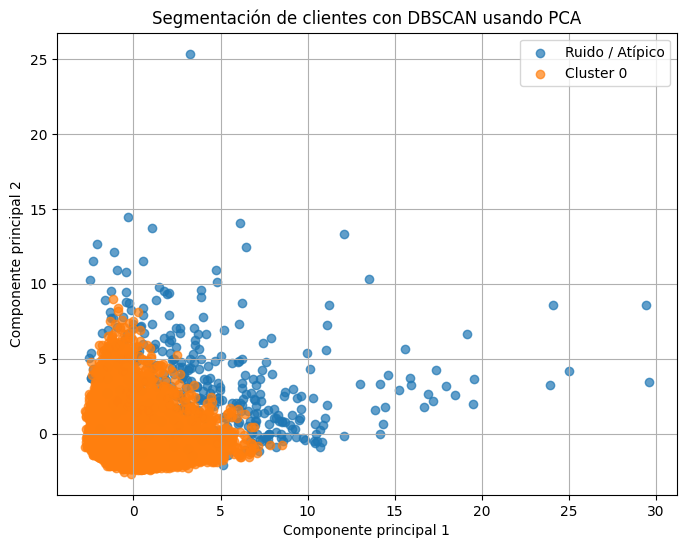

In [15]:
# Gráfica de clusters generados por DBSCAN.
# Cada punto representa un cliente.
# La etiqueta -1 representa clientes atípicos.

plt.figure(figsize=(8, 6))

for cluster in sorted(df_visual["Cluster"].unique()):
    datos_cluster = df_visual[df_visual["Cluster"] == cluster]
    etiqueta = "Ruido / Atípico" if cluster == -1 else f"Cluster {cluster}"

    plt.scatter(
        datos_cluster["PCA_1"],
        datos_cluster["PCA_2"],
        label=etiqueta,
        alpha=0.7
    )

plt.title("Segmentación de clientes con DBSCAN usando PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de la visualización

La gráfica permite observar cómo DBSCAN separa los clientes en diferentes grupos según la densidad de sus comportamientos financieros.

**Convenciones:**

- Los clusters numerados representan grupos de clientes con patrones similares.
- La etiqueta **-1** representa clientes atípicos o ruido.
- La visualización usa PCA, por lo tanto, es una representación reducida del comportamiento real del modelo.

Esta gráfica es útil para explicar el funcionamiento del algoritmo durante una demostración corta de 2 a 3 minutos.

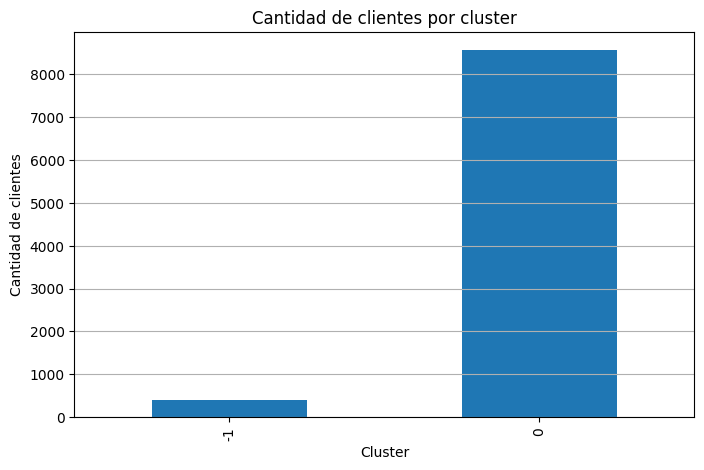

In [16]:
# Gráfica de barras con la cantidad de clientes por cluster.

plt.figure(figsize=(8, 5))
conteo_clusters.plot(kind="bar")

plt.title("Cantidad de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de clientes")
plt.grid(axis="y")
plt.show()

## 10. Serialización del modelo

Para cumplir con la primera entrega, se deben guardar los archivos entrenados en la carpeta `models/`.

Se guardan tres archivos:

```text
models/dbscan_model.pkl
models/scaler.pkl
models/model_info.pkl
```

El archivo `dbscan_model.pkl` contiene el modelo entrenado.  
El archivo `scaler.pkl` contiene el escalador usado antes del entrenamiento.  
El archivo `model_info.pkl` contiene información útil para documentar los resultados.

In [17]:
# Serialización del modelo DBSCAN, el scaler y la información del modelo.

ruta_modelo = "../models/dbscan_model.pkl"
ruta_scaler = "../models/scaler.pkl"
ruta_info = "../models/model_info.pkl"

joblib.dump(dbscan_model, ruta_modelo)
joblib.dump(scaler, ruta_scaler)

model_info = {
    "algorithm": "DBSCAN",
    "dataset": "Credit Card Dataset for Clustering - CCData",
    "source_file": "data/raw/CC GENERAL.csv",
    "processed_file": "data/processed/ccdata_processed.csv",
    "columns": list(df_model.columns),
    "eps": dbscan_model.eps,
    "min_samples": dbscan_model.min_samples,
    "clusters": cantidad_clusters,
    "outliers": cantidad_atipicos,
    "outlier_percentage": porcentaje_atipicos,
    "silhouette_score": silhouette,
    "davies_bouldin_score": davies_bouldin
}

joblib.dump(model_info, ruta_info)

print("Modelo guardado en:", ruta_modelo)
print("Scaler guardado en:", ruta_scaler)
print("Información del modelo guardada en:", ruta_info)

Modelo guardado en: ../models/dbscan_model.pkl
Scaler guardado en: ../models/scaler.pkl
Información del modelo guardada en: ../models/model_info.pkl


In [18]:
# Validación de carga de los archivos serializados.
# Esta celda demuestra que los archivos .pkl pueden cargarse correctamente.

modelo_cargado = joblib.load("../models/dbscan_model.pkl")
scaler_cargado = joblib.load("../models/scaler.pkl")
info_cargada = joblib.load("../models/model_info.pkl")

print("Modelo cargado correctamente:", type(modelo_cargado))
print("Scaler cargado correctamente:", type(scaler_cargado))
print("Información del modelo:")
info_cargada

Modelo cargado correctamente: <class 'sklearn.cluster._dbscan.DBSCAN'>
Scaler cargado correctamente: <class 'sklearn.preprocessing._data.StandardScaler'>
Información del modelo:


{'algorithm': 'DBSCAN',
 'dataset': 'Credit Card Dataset for Clustering - CCData',
 'source_file': 'data/raw/CC GENERAL.csv',
 'processed_file': 'data/processed/ccdata_processed.csv',
 'columns': ['BALANCE',
  'BALANCE_FREQUENCY',
  'PURCHASES',
  'ONEOFF_PURCHASES',
  'INSTALLMENTS_PURCHASES',
  'CASH_ADVANCE',
  'PURCHASES_FREQUENCY',
  'ONEOFF_PURCHASES_FREQUENCY',
  'PURCHASES_INSTALLMENTS_FREQUENCY',
  'CASH_ADVANCE_FREQUENCY',
  'CASH_ADVANCE_TRX',
  'PURCHASES_TRX',
  'CREDIT_LIMIT',
  'PAYMENTS',
  'MINIMUM_PAYMENTS',
  'PRC_FULL_PAYMENT',
  'TENURE'],
 'eps': 2.5,
 'min_samples': 10,
 'clusters': 1,
 'outliers': 386,
 'outlier_percentage': 4.312849162011173,
 'silhouette_score': None,
 'davies_bouldin_score': None}

## 11. Validación de correctitud

La validación se realiza comprobando que:

1. El dataset fue cargado correctamente.
2. No existen valores nulos después del preprocesamiento.
3. Los datos fueron escalados antes de entrenar DBSCAN.
4. El modelo generó etiquetas de cluster.
5. Se identificaron clientes atípicos con la etiqueta `-1`.
6. Los archivos `.pkl` fueron guardados en la carpeta `models/`.
7. Los archivos serializados pueden cargarse correctamente.

Esta validación es suficiente para la primera entrega porque demuestra que el modelo ya fue entrenado y serializado.

In [19]:
# Validaciones finales del proceso.

print("Validación 1 - Dataset original cargado:", df.shape[0] > 0)
print("Validación 2 - Sin nulos en datos procesados:", df_model.isnull().sum().sum() == 0)
print("Validación 3 - Datos escalados:", X_scaled.shape[0] == df_model.shape[0])
print("Validación 4 - Etiquetas generadas:", len(labels) == df_model.shape[0])
print("Validación 5 - Archivo modelo existe:", os.path.exists("../models/dbscan_model.pkl"))
print("Validación 6 - Archivo scaler existe:", os.path.exists("../models/scaler.pkl"))
print("Validación 7 - Archivo info existe:", os.path.exists("../models/model_info.pkl"))

Validación 1 - Dataset original cargado: True
Validación 2 - Sin nulos en datos procesados: True
Validación 3 - Datos escalados: True
Validación 4 - Etiquetas generadas: True
Validación 5 - Archivo modelo existe: True
Validación 6 - Archivo scaler existe: True
Validación 7 - Archivo info existe: True


## 12. Interpretación de resultados

Los resultados del modelo permiten analizar el comportamiento de los clientes de tarjetas de crédito.

La cantidad de clusters encontrados indica cuántos grupos de comportamiento fueron identificados. Por ejemplo, un cluster puede representar clientes con bajo consumo, otro puede representar clientes con alto nivel de compras y otro puede contener clientes con mayor uso de avances en efectivo.

Los clientes marcados con la etiqueta `-1` son considerados atípicos. Esto no significa necesariamente que sean clientes incorrectos o fraudulentos, sino que su comportamiento financiero no se parece al de los grupos principales encontrados por el algoritmo.

Para una entidad financiera, esta información puede ser útil para personalizar campañas, analizar riesgos, revisar clientes con comportamientos inusuales y apoyar la toma de decisiones.

## 13. Conclusiones

- Se implementó el algoritmo **DBSCAN** utilizando librerías de Python, específicamente `scikit-learn`.
- Se trabajó con el dataset **CCData**, enfocado en clientes de tarjetas de crédito.
- Se realizó limpieza de datos, tratamiento de valores nulos y escalado de variables numéricas.
- DBSCAN permitió segmentar clientes y detectar registros atípicos mediante la etiqueta `-1`.
- El modelo fue serializado correctamente en la carpeta `models/`.
- También se guardó el `StandardScaler`, ya que es necesario para aplicar el mismo preprocesamiento en la aplicación.
- El notebook cumple con el avance requerido para la primera entrega: modelo entrenado y archivo `.pkl` generado.

## 14. Referencias

- Scikit-learn. DBSCAN Clustering.  
  https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

- Scikit-learn. StandardScaler.  
  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

- Scikit-learn. Clustering performance evaluation.  
  https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation

- Kaggle. Credit Card Dataset for Clustering - CCData.  
  https://www.kaggle.com/datasets/arjunbhasin2013/ccdata